In [1]:
from pathlib import Path

import pandas as pd
from plotnine import aes, facet_grid, geom_col, ggplot, labs, position_dodge, scale_fill_brewer, theme_bw

from scripts.plot_zebrafish_transfer import collect_metrics


In [2]:
metrics = collect_metrics(Path('outputs'))
summary = (
    metrics.groupby(['time_scale', 'panel', 'variant', 'training', 'eval_gene_set'], as_index=False)
    .agg(
        displacement_mae=('displacement_mae', 'mean'),
        displacement_mse=('displacement_mse', 'mean'),
        velocity_mae=('velocity_mae', 'mean'),
    )
)
summary.sort_values(['time_scale', 'panel', 'displacement_mae']).head(20)


,time_scale,panel,variant,training,eval_gene_set,displacement_mae,displacement_mse,velocity_mae
2,days,10000,cross_attention,zero_shot,full,0.174711,3.336694,1.058876
0,days,10000,cross_attention,fine_tuned,full,0.209956,3.351407,1.146374
1,days,10000,cross_attention,zebrafish_only,full,0.296828,3.414393,1.359761
3,relative,10000,cross_attention,fine_tuned,full,0.131141,3.325231,3.097004
4,relative,10000,cross_attention,zebrafish_only,full,0.156731,3.331003,3.300840
5,relative,10000,cross_attention,zero_shot,full,0.184489,3.347980,3.511789


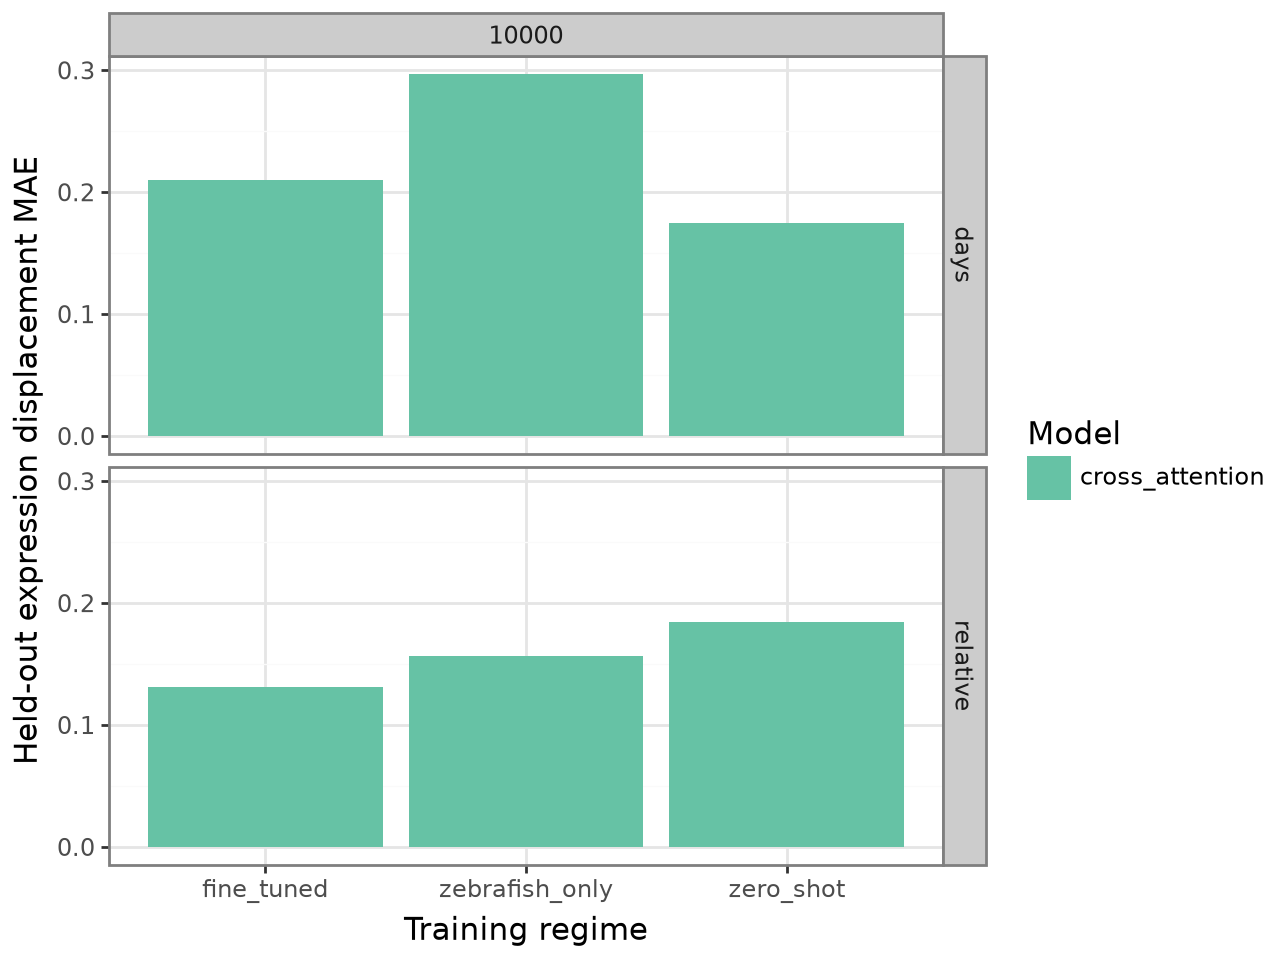

In [3]:
(
    ggplot(summary, aes('training', 'displacement_mae', fill='variant'))
    + geom_col(position=position_dodge(width=0.8))
    + facet_grid('time_scale ~ panel')
    + scale_fill_brewer(type='qual', palette='Set2')
    + labs(x='Training regime', y='Held-out expression displacement MAE', fill='Model')
    + theme_bw()
)
